In [38]:
import os
import tiktoken
import torch
import matplotlib.pyplot as plt

from dataset import create_dataloader
from model import GPTModel
from config import GPT_TRAIN_CONFIG
from generate import generate

Matplotlib is building the font cache; this may take a moment.


In [3]:
try:
    file_name= "data_verdict.txt"
    f=open(file=file_name, mode="r",encoding="utf-8")
    text=f.read()
    f.close()
except IOError:
    print(f"we found a problem opening: { file_name}")

In [8]:
tokenizer=tiktoken.get_encoding("gpt2")

In [12]:
split=int(0.9*len(text))
train_data=text[:split]
val_data=text[split:]

In [28]:
train_loader=create_dataloader(txt=train_data, batch_size=2, max_length=256, stride=256,
                      shuffle=True, drop_last=True, num_workers=0)
val_loader=create_dataloader(txt=val_data, batch_size=2, max_length=256, stride=256,
                      shuffle=False, drop_last=True, num_workers=0)

In [32]:
epoch=4
lr=1e-4

In [41]:
device="cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(123)
model= GPTModel(GPT_TRAIN_CONFIG).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_losses, val_losses = [], []
sample_prompt = "Hello, I am"


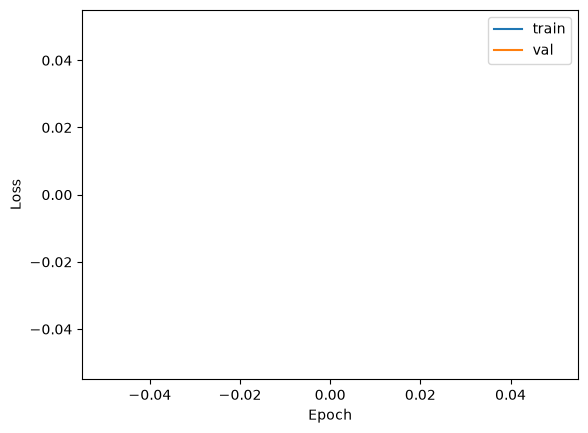

Model saved to pretrained_model.pth


In [ ]:

for _ in range(epochs):
    print('hi')
    model.train()
    epoch_loss, n = 0.0, 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(inputs).flatten(0, 1)
        loss   = torch.nn.functional.cross_entropy(logits, targets.flatten())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n += 1
    train_losses.append(epoch_loss / n)

        # --- validation ---
    model.eval()
    val_loss, n = 0.0, 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = model(inputs).flatten(0, 1)
            val_loss += torch.nn.functional.cross_entropy(logits, targets.flatten()).item()
            n += 1
        sample_ids = generate(model, text_to_ids(sample_prompt, tokenizer, device),
                                   max_new_tokens=5, context_size=cfg["context_length"])
    val_losses.append(val_loss / n)

    print(f"Epoch {ep:3d} | train={train_losses[-1]:.4f} | val={val_losses[-1]:.4f}")
    print(f"  Sample: {ids_to_text(sample_ids, tokenizer)}")

# Plot
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses,   label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("pretrain_loss.png")
plt.show()

torch.save(model.state_dict(), "pretrained_model.pth")
print("Model saved to pretrained_model.pth")